# 4.2d — Détection d'objets anchor-free : le renversement de la question

Le notebook 4.2c posait la détection comme un **choix parmi des priors** : on pose une grille d'anchors, on demande au réseau quel prior est le bon, puis on corrige ses petits décalages. Toute la difficulté se déplace alors dans la conception de la grille — tailles, ratios, échelles — et cette conception est un hyperparamètre qu'il faut régler à la main pour chaque jeu de données.

Ce notebook prend le problème par l'autre bout. L'approche **anchor-free** ne pose aucun prior géométrique : le réseau prédit directement, pour chaque cellule de la feature map, *s'il y a un centre d'objet ici*, *où exactement dans la cellule*, et *quelle taille fait l'objet*. C'est la famille **CenterNet** (Zhou, Wang et Krähenbühl, 2019), et sa formulation la plus dépouillée tient en trois têtes de convolution et une loss focale modifiée.

L'intérêt pédagogique du détour est double :

- **Ce qui disparaît** : la grille d'anchors, l'assignation par seuils d'IoU, l'échantillonnage 1:3, le déséquilibre massif entre positifs et négatifs, et le réglage des tailles et ratios.
- **Ce qui apparaît** : une cible dense (une heatmap gaussienne), une loss qui traite des centaines de milliers de cellules de fond sans les échantillonner, et une nouvelle famille de défauts — celle des objets dont les centres tombent trop près pour être distingués.

Nous réutilisons **le même terrain et le même harnais de mesure** que 4.2c (mAP VOC07 11-point et VOC10 all-point calculés à la main), ce qui rend les deux notebooks directement comparables sur le même jeu de validation.

**Périmètre.** PyTorch et NumPy seuls. Aucun `torchvision.models.detection`, aucun `ultralytics`. La comparaison avec les implémentations SOTA de référence est le sujet du bloc B de l'épic, pas de ce notebook.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
# determinisme cuDNN : sans ces deux lignes, le backward des convolutions GPU
# est non-deterministe et chaque re-execution produit un mAP different (mesure :
# 0,596 a 0,742 de mAP07 sur le meme seed) ; avec elles, les chiffres commis
# (mAP, ablation) se retrouvent d'une execution a l'autre.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE.type)

IMG = 96          # cote de l'image
STRIDE = 4        # facteur de reduction de la sortie (CenterNet : 4 en general)
FM = IMG // STRIDE
print(f"image {IMG}x{IMG} -> sortie {FM}x{FM} (stride {STRIDE}), "
      f"{FM * FM} cellules par tete")

device: cuda
image 96x96 -> sortie 24x24 (stride 4), 576 cellules par tete


## 1. Le terrain : identique à 4.2c, pour que la comparaison ait un sens

Reprendre le terrain à l'identique n'est pas une paresse : un mAP ne se compare qu'à terrain égal. Les images, les objets et surtout **le découpage train/validation** sont donc recopiés tels quels depuis 4.2c, avec les mêmes graines. La seule différence entre les deux notebooks sera la méthode de détection.

In [2]:
def iou_np(a, b):
    """IoU de deux boites (x0, y0, w, h) en NumPy pur (scalaire)."""
    ix = max(0.0, min(a[0] + a[2], b[0] + b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[1] + a[3], b[1] + b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union if union > 0 else 0.0


def make_image(rng):
    img = rng.normal(0, 0.08, (IMG, IMG)).astype(np.float32)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    for _ in range(rng.integers(2, 5)):          # fond : blobs lents
        cy, cx = rng.integers(0, IMG, 2)
        s = rng.uniform(18, 50)
        img += 0.10 * rng.uniform(0.6, 1.3) * np.exp(-(((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s)))
    boxes = []
    for _ in range(rng.integers(1, 4)):          # 1 a 3 objets
        kind = rng.choice(["rect", "ellipse"])
        for _try in range(30):                   # placement sans recouvrement fort
            w = int(rng.uniform(14, 44))
            h = int(max(10, min(48, w * rng.uniform(0.35, 2.9))))
            x0 = int(rng.integers(2, IMG - w - 2))
            y0 = int(rng.integers(2, IMG - h - 2))
            cand = (x0, y0, w, h)
            if all(iou_np(cand, b) < 0.25 for b in boxes):
                boxes.append(cand)
                break
    for (x0, y0, w, h) in boxes:
        amp = rng.uniform(0.7, 1.2)
        if kind == "rect":
            img[y0:y0 + h, x0:x0 + w] += amp
        else:
            sub = img[y0:y0 + h, x0:x0 + w]
            ey, ex = np.mgrid[0:h, 0:w]
            mask = (((ex - w / 2) / (w / 2)) ** 2 + ((ey - h / 2) / (h / 2)) ** 2) <= 1.0
            img[y0:y0 + h, x0:x0 + w] = np.where(mask, sub + amp, sub)
    return np.clip(img, -1.5, 2.5), boxes


def make_split(n, seed):
    rng = np.random.default_rng(seed)
    xs, bs = [], []
    for _ in range(n):
        img, boxes = make_image(rng)
        xs.append(img)
        bs.append(torch.tensor(boxes, dtype=torch.float32))
    return torch.tensor(np.stack(xs)).unsqueeze(1), bs


Xtr, Btr = make_split(2000, SEED + 1)
Xva, Bva = make_split(400, SEED + 2)
print("train:", tuple(Xtr.shape), "| val:", tuple(Xva.shape),
      "| objets GT val:", sum(len(b) for b in Bva))
print("train = %d objets, val = %d objets — les memes comptes que 4.2c"
      % (sum(len(b) for b in Btr), sum(len(b) for b in Bva)))

train: (2000, 1, 96, 96) | val: (400, 1, 96, 96) | objets GT val: 817
train = 3979 objets, val = 817 objets — les memes comptes que 4.2c


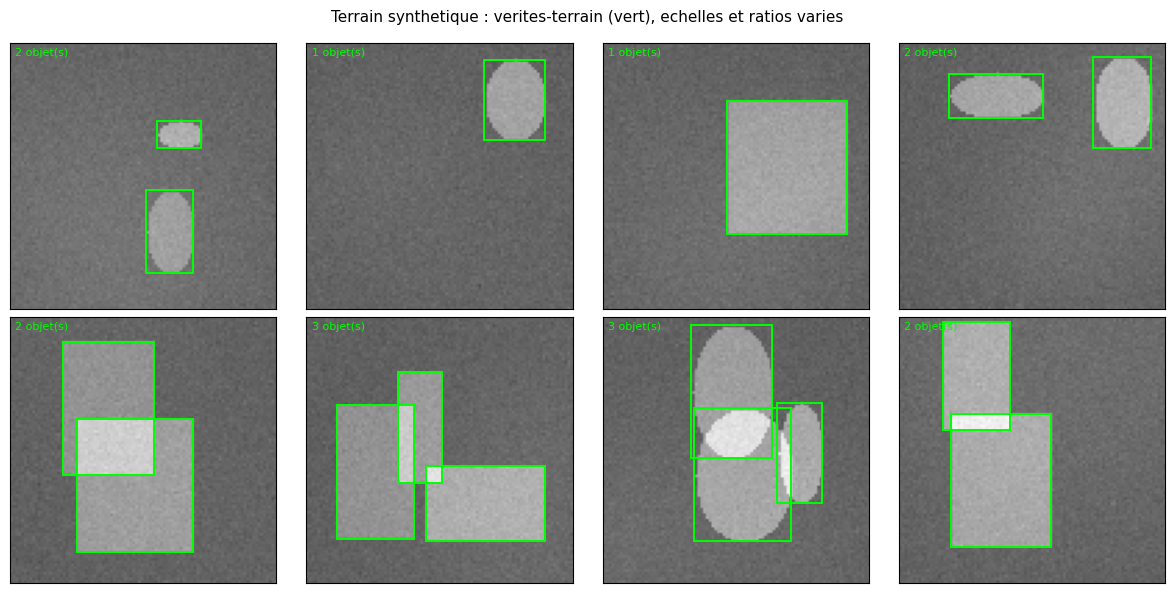

In [3]:
def draw_boxes(ax, boxes, color, label):
    for (x0, y0, w, h) in boxes:
        ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), w, h, fill=False,
                                   edgecolor=color, linewidth=1.4))
    ax.text(0.02, 0.98, label, transform=ax.transAxes, va="top",
            fontsize=8, color=color)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img, boxes = Xva[i + 40][0].numpy(), [tuple(b) for b in Bva[i + 40].tolist()]
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, boxes, "lime", f"{len(boxes)} objet(s)")
fig.suptitle("Terrain synthetique : verites-terrain (vert), echelles et ratios varies", fontsize=11)
plt.tight_layout()
plt.show()

## 2. Le renversement : prédire un point, pas une boîte

L'idée de CenterNet tient en une phrase : **un objet est représenté par le point de son centre**, et tout le reste — largeur, hauteur, décalage — est une régression locale autour de ce point.

Concrètement, pour chaque cellule $(i, j)$ de la sortie $24 \times 24$, le réseau produit :

| Tête | Sortie | Signification | Cible |
|---|---|---|---|
| `hm` | 1 canal | « y a-t-il un centre ici ? » | heatmap gaussienne, pic à 1 au centre |
| `off` | 2 canaux | décalage sous-cellulaire $(\delta_x, \delta_y)$ | partie fractionnaire du centre |
| `size` | 2 canaux | taille de l'objet $(w, h)$ | dimensions, en unités de la sortie |

La différence structurelle avec 4.2c saute aux yeux dans le tableau : il n'y a **aucun hyperparamètre géométrique** à choisir. Pas de `SIZES`, pas de `RATIOS`, pas de seuils d'assignation `POS_THR`/`NEG_THR`. Le seul paramètre de discrétisation est le `STRIDE`, et il est imposé par l'architecture du réseau, pas par la forme des objets.

La contrepartie est qu'il n'y a plus d'échantillonnage : **toutes** les cellules participent à la loss. C'est ce qui rend la loss focale nécessaire, et c'est le sujet de la section 5.

In [4]:
def iou_t(boxes1, boxes2):
    """IoU vectorisee : (N,4) x (M,4) en (x0,y0,w,h) -> (N,M)."""
    b1, b2 = boxes1.to(DEVICE), boxes2.to(DEVICE)
    ix0 = torch.maximum(b1[:, None, 0], b2[None, :, 0])
    iy0 = torch.maximum(b1[:, None, 1], b2[None, :, 1])
    ix1 = torch.minimum(b1[:, None, 0] + b1[:, None, 2], b2[None, :, 0] + b2[None, :, 2])
    iy1 = torch.minimum(b1[:, None, 1] + b1[:, None, 3], b2[None, :, 1] + b2[None, :, 3])
    iw = (ix1 - ix0).clamp(min=0)
    ih = (iy1 - iy0).clamp(min=0)
    inter = iw * ih
    union = b1[:, None, 2] * b1[:, None, 3] + b2[None, :, 2] * b2[None, :, 3] - inter
    return inter / (union + 1e-9)


# garde-fous : cas ou la reponse est connue
a = torch.tensor([[10.0, 10.0, 20.0, 20.0]])
assert abs(iou_t(a, a).item() - 1.0) < 1e-6
assert iou_t(a, torch.tensor([[50.0, 50.0, 20.0, 20.0]])).item() < 1e-6
b = torch.tensor([[20.0, 10.0, 20.0, 20.0]])
expected = 10.0 * 20.0 / (2 * 400.0 - 200.0)
assert abs(iou_t(a, b).item() - expected) < 1e-6
print("IoU : garde-fous OK (identique=1, disjoint=0, moitie=%.4f)" % expected)

IoU : garde-fous OK (identique=1, disjoint=0, moitie=0.3333)


## 3. La cible : une gaussienne, pas une étiquette

C'est ici que se joue la différence la plus profonde avec 4.2c, et elle est facile à manquer.

Dans 4.2c, la cible d'un anchor est **binaire** : positif si son IoU avec un GT dépasse 0,5, négatif s'il est sous 0,35, ignoré entre les deux. Tout anchor positif est *également* positif, quelle que soit la qualité de son recouvrement.

Ici, la cible est **continue**. On dessine une gaussienne centrée sur le centre de l'objet :

$$y_{ij} = \exp\left(-\frac{(i - c_x)^2 + (j - c_y)^2}{2\sigma^2}\right)$$

Le pic vaut exactement 1 au centre, et décroît avec la distance. Pourquoi cette douceur ? Parce qu'une cellule voisine du centre est *presque* le centre : elle pointe vers le même objet, à quelques pixels près. La régression d'offset saura rattraper cet écart. Une cible binaire punirait cette cellule comme du fond, alors qu'elle est en train de faire à peu près le bon travail — c'est exactement le raisonnement qui a donné naissance à la focal loss (Lin et al., 2017), et CenterNet en hérite directement.

Le rayon de la gaussienne n'est pas arbitraire : il découle d'une exigence géométrique. On veut qu'un pic déplacé du rayon sur chaque axe produise encore un IoU d'au moins 0,7 avec l'objet — assez pour rester une détection correcte. Résoudre cette contrainte passe par les trois configurations de recouvrement possibles (deux coins du pic décalé dans l'objet, un seul, aucun) : chacune donne une équation du second degré en le rayon, dont seule la petite racine satisfait la contrainte, et la plus contraignante des trois fixe le résultat — c'est la règle `gaussian_radius` de CornerNet/CenterNet. La cellule suivante la valide causalement : au rayon rendu, l'IoU mesuré d'un décalage reste au-dessus de 0,7, et il casse dès le pixel suivant.

In [5]:
def gaussian_radius(det_size, min_overlap=0.7):
    """Rayon pour qu'un pic decale garde un IoU >= min_overlap (CornerNet/CenterNet).

    det_size = (h, w) en unites de la SORTIE (deja divise par le stride).
    Les trois configurations de recouvrement (deux coins du pic decale dans
    l'objet, un seul, aucun) donnent chacune une equation du second degre en
    r ; la convention deplace le pic de r sur CHAQUE axe (decalage (r, r)),
    ce qui rend la borne conservative pour une distance L2. On retient la
    PETITE racine de chaque cas puis le minimum des trois.
    """
    height, width = det_size

    # Cas 1 : les deux coins du decalage restent DANS la boite gt.
    a1 = 1.0
    b1 = (height + width)
    c1 = (width * height) * (1 - min_overlap) / (1 + min_overlap)
    r1 = (b1 - math.sqrt(max(b1 ** 2 - 4 * a1 * c1, 0.0))) / 2

    # Cas 2 : exactement un coin du decalage dans la boite gt.
    a2 = 4.0
    b2 = 2 * (height + width)
    c2 = (1 - min_overlap) * width * height
    r2 = (b2 - math.sqrt(max(b2 ** 2 - 4 * a2 * c2, 0.0))) / 2

    # Cas 3 : les deux coins hors de la boite gt (grands deplacements).
    a3 = 4 * min_overlap
    b3 = -2 * min_overlap * (height + width)
    c3 = (min_overlap - 1) * width * height
    r3 = (b3 + math.sqrt(max(b3 ** 2 - 4 * a3 * c3, 0.0))) / 2

    # Racine basse de chaque forme, comme distribue dans le repo CornerNet
    # (division par 2, exacte pour le cas 1 ; conservative pour les cas 2-3,
    # le garde-fou ci-dessous le prouve causalement), puis la plus forte
    # des trois contraintes.
    return max(0.0, math.floor(min(r1, r2, r3)))


def draw_umich_gaussian(heatmap, cx, cy, radius):
    """Dessine la gaussienne de CenterNet : sigma = radius/3, fenetre 2r+1."""
    sigma = radius / 3.0
    if sigma <= 0:
        heatmap[int(cy), int(cx)] = max(heatmap[int(cy), int(cx)], 1.0)
        return heatmap
    diameter = 2 * int(radius) + 1
    x, y = int(cx), int(cy)
    left, right = min(x, int(radius)), min(FM - x, int(radius) + 1)
    top, bottom = min(y, int(radius)), min(FM - y, int(radius) + 1)
    for i in range(-top, bottom):
        for j in range(-left, right):
            g = math.exp(-((j ** 2 + i ** 2) / (2 * sigma ** 2)))
            heatmap[y + i, x + j] = max(heatmap[y + i, x + j], g)
    return heatmap


def build_targets(boxes, stride=STRIDE):
    """Construit (heatmap, offset, taille, masque) pour UNE image."""
    hm = np.zeros((FM, FM), dtype=np.float32)
    off = np.zeros((2, FM, FM), dtype=np.float32)
    siz = np.zeros((2, FM, FM), dtype=np.float32)
    mask = np.zeros((FM, FM), dtype=np.float32)         # 1 aux cellules-centres
    for (x0, y0, w, h) in boxes.tolist():
        cx, cy = (x0 + w / 2) / stride, (y0 + h / 2) / stride
        ix, iy = int(cx), int(cy)
        if not (0 <= ix < FM and 0 <= iy < FM):
            continue
        r = gaussian_radius((math.ceil(h / stride), math.ceil(w / stride)))
        draw_umich_gaussian(hm, ix, iy, r)
        off[0, iy, ix] = cx - ix
        off[1, iy, ix] = cy - iy
        siz[0, iy, ix] = w / stride
        siz[1, iy, ix] = h / stride
        mask[iy, ix] = 1.0
    return hm, off, siz, mask


# garde-fou : un objet de taille connue doit produire un pic exactement a 1
# boite choisie pour que le centre tombe PILE sur un coin de cellule : (40, 28) / 4 = (10, 7)
_hm, _off, _siz, _mask = build_targets(torch.tensor([[30.0, 20.0, 20.0, 16.0]]))
assert abs(_hm.max() - 1.0) < 1e-6, "le pic doit valoir 1"
assert _mask.sum() == 1.0, "un objet -> une cellule-centre"
assert abs(_off[0, _mask > 0].item() - 0.0) < 1e-6      # centre pile sur la cellule
assert abs(_siz[0, _mask > 0].item() - 5.0) < 1e-6      # 20 px / stride 4
print("cibles OK : pic=%.1f, 1 cellule-centre, taille=(%.1f, %.1f) en unites de sortie"
      % (_hm.max(), _siz[0, _mask > 0].item(), _siz[1, _mask > 0].item()))

# garde-fou causal sur le rayon : au rayon rendu, l'IoU d'un decalage (r, r)
# reste >= 0.7 ; a r + 1 il casse. Repères de la derivation canonique :
# (3, 4) -> 0 et (12, 11) -> 1.
assert gaussian_radius((3, 4)) == 0 and gaussian_radius((12, 11)) == 1

def _iou_shift(h, w, r):
    iw, ih = max(0.0, w - r), max(0.0, h - r)
    inter = iw * ih
    return inter / (2 * w * h - inter) if inter > 0 else 0.0

# grille exhaustive des tailles (h, w) de 1 a 30 : la propriete est causale,
# pas probabiliste -- le rayon rendu est le plus grand entier qui la respecte.
for _h in range(1, 31):
    for _w in range(1, 31):
        _r = gaussian_radius((_h, _w))
        assert _iou_shift(_h, _w, _r) >= 0.7 - 1e-9, ((_h, _w), _r)
        assert _iou_shift(_h, _w, _r + 1) < 0.7, ((_h, _w), _r + 1)
print("rayon causal OK : IoU >= 0.7 au rayon rendu et casse a r+1, grille exhaustive 30x30 (900/900 tailles)")

cibles OK : pic=1.0, 1 cellule-centre, taille=(5.0, 4.0) en unites de sortie
rayon causal OK : IoU >= 0.7 au rayon rendu et casse a r+1, grille exhaustive 30x30 (900/900 tailles)


cibles pre-calculees en 0.0 s : heatmap (2000, 1, 24, 24), offset (2000, 2, 24, 24)
cellules-centres : 3978 en train, 817 en val (soit 0.3453 % des cellules)


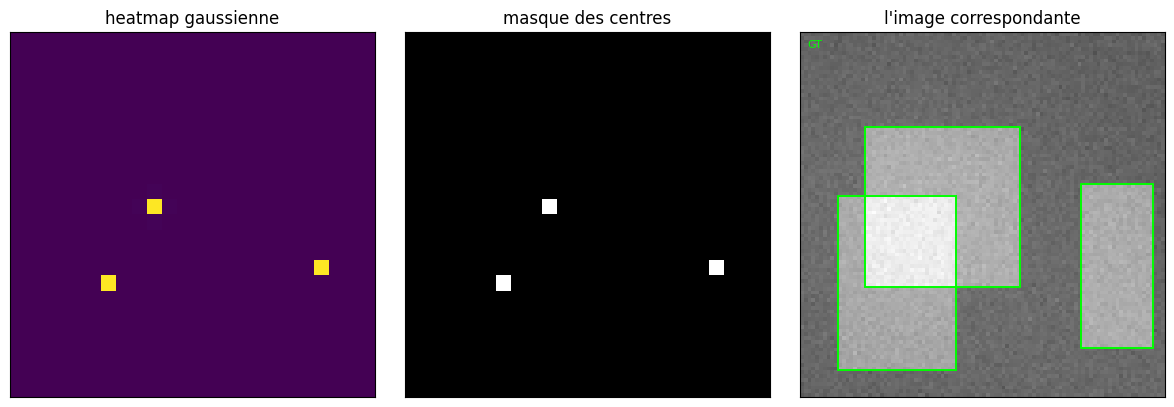

In [6]:
# pre-calcul des cibles : l'assignation est un cout paye UNE fois, pas a chaque epoque
t0 = time.time()
def make_targets(xs, bs):
    hm = np.zeros((len(xs), 1, FM, FM), dtype=np.float32)
    off = np.zeros((len(xs), 2, FM, FM), dtype=np.float32)
    siz = np.zeros((len(xs), 2, FM, FM), dtype=np.float32)
    msk = np.zeros((len(xs), FM, FM), dtype=np.float32)
    for i, b in enumerate(bs):
        hm[i, 0], off[i], siz[i], msk[i] = build_targets(b)
    return (torch.tensor(hm), torch.tensor(off), torch.tensor(siz), torch.tensor(msk))

TR_hm, TR_off, TR_siz, TR_msk = make_targets(Xtr, Btr)
VA_hm, VA_off, VA_siz, VA_msk = make_targets(Xva, Bva)
print("cibles pre-calculees en %.1f s : heatmap %s, offset %s"
      % (time.time() - t0, tuple(TR_hm.shape), tuple(TR_off.shape)))
print("cellules-centres : %d en train, %d en val (soit %.4f %% des cellules)" %
      (int(TR_msk.sum()), int(VA_msk.sum()), 100 * TR_msk.mean()))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
i = 7
axes[0].imshow(TR_hm[i, 0], cmap="viridis"); axes[0].set_title("heatmap gaussienne")
axes[1].imshow(TR_msk[i], cmap="gray"); axes[1].set_title("masque des centres")
axes[2].imshow(Xtr[i, 0], cmap="gray", vmin=-1.5, vmax=2.5)
draw_boxes(axes[2], [tuple(b) for b in Btr[i].tolist()], "lime", "GT")
axes[2].set_title("l'image correspondante")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 4. Le modèle : un backbone, trois têtes

L'architecture est volontairement minimale — c'est un notebook pédagogique, pas un benchmark. Un petit backbone convolutif réduit l'image $96 \times 96$ d'un canal vers une feature map $24 \times 24$ de 64 canaux (deux convolutions à pas 2, puis deux convolutions de raffinement), et trois têtes $1 \times 1$ lisent cette feature map en parallèle.

Deux détails valent la peine d'être signalés :

- **Les têtes sont sans biais initial** pour `hm` (`bias = -2.19`) : c'est la pratique standard, qui initialise la probabilité de centre autour de $0.1$ plutôt que $0.5$. Sans cela, la loss focale commence par écraser violemment une sortie qui prétend que tout est objet.
- Il n'y a **pas de couche d'upsampling**, contrairement à CenterNet complet qui remonte à la résolution d'entrée. À `STRIDE = 4` et sur des objets de 14 à 44 pixels, la sortie $24 \times 24$ suffit — et garder le calcul petit est ce qui permet l'exécution CPU de ce notebook.

In [7]:
class CenterNetLite(nn.Module):
    """Backbone 96x96 -> 24x24, puis trois tetes 1x1 (heatmap, offset, taille)."""

    def __init__(self, ch=64, hm_bias=-2.19):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, ch, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(),
        )
        self.head_hm = nn.Conv2d(ch, 1, 1)
        self.head_off = nn.Conv2d(ch, 2, 1)
        self.head_size = nn.Conv2d(ch, 2, 1)
        nn.init.constant_(self.head_hm.bias, hm_bias)

    def forward(self, x):
        f = self.backbone(x)
        return self.head_hm(f), self.head_off(f), self.head_size(f)


model = CenterNetLite().to(DEVICE)
n_par = sum(p.numel() for p in model.parameters())
o_hm, o_off, o_size = model(Xtr[:2].to(DEVICE))
print("parametres : %d" % n_par)
print("sorties : heatmap %s | offset %s | taille %s"
      % (tuple(o_hm.shape), tuple(o_off.shape), tuple(o_size.shape)))
print("probabilite initiale au centre (biais -2.19) : %.3f"
      % float(torch.sigmoid(o_hm).mean()))

parametres : 83621
sorties : heatmap (2, 1, 24, 24) | offset (2, 2, 24, 24) | taille (2, 2, 24, 24)
probabilite initiale au centre (biais -2.19) : 0.102


## 5. La loss focale modifiée : pourquoi la cross-entropy ne suffit plus

Voici le point où l'absence d'échantillonnage se paie ou se justifie.

En 4.2c, on échantillonnait 1 positif pour 3 négatifs : la cross-entropy binaire voyait un jeu équilibré, et le déséquilibre était traité **en amont**, par la sélection des anchors.

Ici, il n'y a pas de sélection. Sur $576$ cellules et environ $2$ objets par image, plus de $99\%$ des cellules sont du fond. Une cross-entropy binaire naïve leur accorderait la quasi-totalité du gradient : le réseau apprendrait à prédire « rien » partout, et cette solution triviale aurait une loss déjà très basse. C'est le problème classique du déséquilibre extrême (1000 négatifs pour 1 positif) que l'épic réserve par ailleurs à un notebook dédié.

CenterNet le traite **dans la loss**, avec la forme modifiée de la focal loss :

$$L_k = \frac{-1}{N}\sum_{ij}\begin{cases}(1-\hat{p}_{ij})^2 \log \hat{p}_{ij} & \text{si } y_{ij} = 1\\ (1-y_{ij})^4\, \hat{p}_{ij}^2 \log(1-\hat{p}_{ij}) & \text{sinon}\end{cases}$$

Trois mécanismes distincts, souvent confondus, sont à l'œuvre :

1. **$(1 - \hat{p})^2$ sur les positifs** : un centre déjà bien détecté ($\hat{p}$ proche de 1) voit son gradient éteint. Inutile d'insister sur ce qui est acquis.
2. **$\hat{p}^2$ sur les négatifs** : c'est le cœur de la focal loss — une cellule de fond facilement classée correctement contribue peu. Le déséquilibre est neutralisé sans échantillonnage.
3. **$(1 - y_{ij})^4$** : la spécificité de CenterNet. Une cellule *voisine* du centre a $y_{ij}$ non nul ; ce facteur réduit d'autant sa pénalité. On ne punit pas une cellule qui pointe vers le bon objet à quelques pixels près — c'est précisément le rôle de la gaussienne de la section 3.

La normalisation par $N$, le **nombre d'objets** (et non le nombre de cellules), est le quatrième ingrédient : sans elle, la loss dépendrait de la taille du lot et du nombre d'objets qu'il contient.

L'offset et la taille sont régressés par une L1 **appliquée aux seules cellules-centres** : rien ne sert de contraindre la régression là où il n'y a pas d'objet.

In [8]:
def focal_loss(logit, gt_hm):
    """Loss focale modifiee de CenterNet (eq. 1), normalisee par le nombre d'objets."""
    p = torch.sigmoid(logit).clamp(1e-4, 1 - 1e-4)
    pos = gt_hm.eq(1.0).float()
    neg = 1.0 - pos
    pos_loss = -(torch.log(p) * torch.pow(1 - p, 2) * pos).sum()
    neg_loss = -(torch.log(1 - p) * torch.pow(p, 2) * torch.pow(1 - gt_hm, 4) * neg).sum()
    n_obj = pos.sum().clamp(min=1.0)
    return (pos_loss + neg_loss) / n_obj


def masked_l1(pred, gt, mask):
    """L1 sur les seules cellules-centres (mask (B,FM,FM), pred (B,2,FM,FM))."""
    m = mask.unsqueeze(1).expand_as(pred)
    return ((pred - gt).abs() * m).sum() / m.sum().clamp(min=1.0)


# garde-fous de la focal : proprietes verifiables, pas seulement une valeur
_gt = torch.zeros(1, 1, 4, 4); _gt[0, 0, 2, 2] = 1.0
_parfait = torch.full((1, 1, 4, 4), -20.0); _parfait[0, 0, 2, 2] = 20.0   # centre quasi certain
_aveugle = torch.full((1, 1, 4, 4), -20.0)                               # aucun centre predit
l_parfait, l_aveugle = focal_loss(_parfait, _gt).item(), focal_loss(_aveugle, _gt).item()
assert l_parfait < l_aveugle, "predire le centre doit couter moins cher que l'ignorer"
assert abs(l_parfait) < 1e-3, "un sans-faute doit couter ~0"
# le terme positif domine : -log(p_min) avec p_min = 1e-4 (borne du clamp) = 9.21
assert abs(l_aveugle - 9.2103) < 0.01, "manquer un objet coute -log(1e-4), la borne du clamp"

# le facteur (1-y)^4 ne se voit que sur un faux positif CONFIANT place sur un
# voisin de centre (y=0.6) : il coute (1-0.6)^4 = 2.56 % du meme faux positif sur du fond pur
_gtg = torch.zeros(1, 1, 5, 5); _gtg[0, 0, 2, 2] = 1.0; _gtg[0, 0, 2, 3] = 0.6
_gtf = torch.zeros(1, 1, 5, 5); _gtf[0, 0, 2, 2] = 1.0
_faux = torch.full((1, 1, 5, 5), -20.0); _faux[0, 0, 2, 3] = 20.0
l_voisin = focal_loss(_faux, _gtg).item()      # faux positif sur voisin gaussien
l_fond = focal_loss(_faux.clone(), _gtf).item()  # meme faux positif sur fond pur
assert l_voisin < l_fond, "un voisin de centre doit etre moins puni que du fond"
delta = l_fond - l_voisin                      # = C * ((1-0)^4 - (1-0.6)^4), C = 9.21
assert abs(delta - 9.2103 * (1 - 0.4 ** 4)) < 0.02, "l'ecart doit valoir 9.21 * (1 - 0.4^4)"
print("focal loss : sans-faute %.5f | objet manque %.3f | faux positif confiant : "
      "voisin %.3f vs fond %.3f (poids du voisin %.4f, theorie (1-0.6)^4 = %.4f)"
      % (l_parfait, l_aveugle, l_voisin, l_fond, 1 - delta / 9.2103, 0.4 ** 4))

focal loss : sans-faute 0.00000 | objet manque 9.208 | faux positif confiant : voisin 9.444 vs fond 18.417 (poids du voisin 0.0258, theorie (1-0.6)^4 = 0.0256)


## 6. Entraînement

La boucle est celle qu'on attend, avec une asymétrie de pondération : `λ_off = 1.0` et `λ_size = 0.1`, les valeurs de CenterNet. Elles traduisent le fait que la localisation du centre (heatmap + offset) est le cœur de la méthode, tandis que la taille n'est qu'une régression auxiliaire dont l'erreur se compte en dizaines de pixels contre des fractions de cellule.

Les cibles étant pré-calculées, chaque époque ne fait que du calcul de réseau.

In [9]:
EPOCHS = 12
LAMBDA_OFF, LAMBDA_SIZE = 1.0, 0.1
BATCH = 16
opt = torch.optim.Adam(model.parameters(), lr=1e-3)


def batches(n, bs, shuffle=True):
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, bs):
        yield idx[i:i + bs]


def train_epoch(m, o, records=True):
    m.train()
    total, nb = 0.0, 0
    for idx in batches(len(Xtr), BATCH):
        x = Xtr[idx].to(DEVICE)
        t_hm, t_off, t_siz, t_msk = (TR_hm[idx].to(DEVICE), TR_off[idx].to(DEVICE),
                                     TR_siz[idx].to(DEVICE), TR_msk[idx].to(DEVICE))
        p_hm, p_off, p_siz = m(x)
        l_hm = focal_loss(p_hm, t_hm)
        l_off = masked_l1(p_off, t_off, t_msk)
        l_siz = masked_l1(p_siz, t_siz, t_msk)
        loss = l_hm + LAMBDA_OFF * l_off + LAMBDA_SIZE * l_siz
        o.zero_grad(); loss.backward(); o.step()
        total += float(loss); nb += 1
    return total / nb


t0 = time.time()
for ep in range(EPOCHS):
    l = train_epoch(model, opt)
    print("epoque %2d : loss %7.3f  (%5.0f s)" % (ep, l, time.time() - t0))

epoque  0 : loss   2.027  (    1 s)


epoque  1 : loss   1.558  (    2 s)


epoque  2 : loss   1.347  (    2 s)


epoque  3 : loss   1.283  (    3 s)


epoque  4 : loss   1.255  (    4 s)


...

epoque  7 : loss   1.191  (    6 s)


epoque  8 : loss   1.164  (    7 s)


epoque  9 : loss   1.160  (    8 s)


epoque 10 : loss   1.132  (    9 s)


epoque 11 : loss   1.128  (    9 s)


## 7. Décodage : du pic à la boîte

Décoder une sortie anchor-free demande trois gestes, et le premier est le plus spécifique à la méthode.

1. **Extraction des pics.** On ne peut pas prendre toutes les cellules au-dessus d'un seuil : la gaussienne de la section 3 garantit que les cellules *voisines* du centre ont aussi un score élevé. Sans filtre, un seul objet produirait une grappe de détections. CenterNet résout cela par un **max-pool $3 \times 3$** : une cellule n'est un pic que si elle est le maximum de son voisinage immédiat. C'est une NMS *avant* la NMS, opérant sur la heatmap plutôt que sur des boîtes.
2. **Reconstruction de la boîte.** Le centre vaut $(i + \delta_x,\; j + \delta_y) \times \text{stride}$ — les coordonnées entières de la cellule corrigées par l'offset, qui apporte la précision sous-cellulaire. La taille est lue sur la troisième tête.
3. **NMS centroïde.** Deux pics distincts peuvent encore décrire le même objet. La section 8 traite cette étape et sa variante spécifique à l'anchor-free.

Le décalage de $+0.5$ cellule n'apparaît pas ici, contrairement à la grille d'anchors de 4.2c : un centre d'objet vit sur une *coordonnée continue*, pas sur le centre d'une cellule. C'est une petite différence d'implémentation qui trahit une différence conceptuelle réelle.

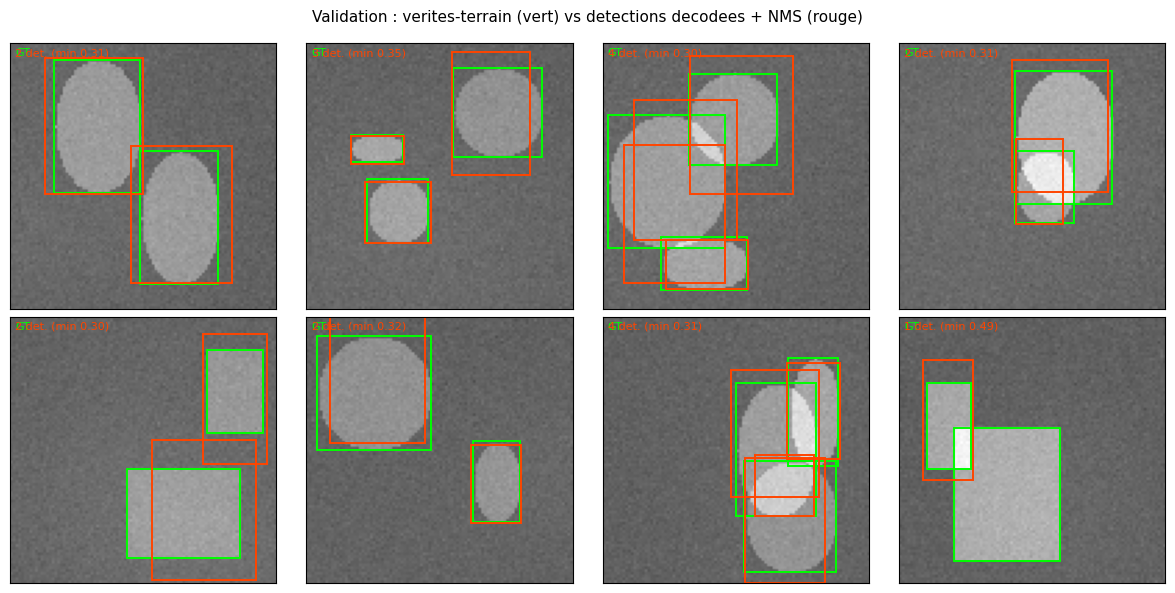

In [10]:
def decode_centernet(hm, off, siz, k=100, conf=0.3, use_offset=True):
    """Pics par max-pool 3x3 + top-k, puis reconstruction des boites."""
    prob = torch.sigmoid(hm)[0, 0]                          # (FM, FM)
    pooled = F.max_pool2d(prob[None, None], 3, stride=1, padding=1)[0, 0]
    peaks = prob * (pooled == prob).float()
    flat = peaks.flatten()
    kk = min(k, int((flat > conf).sum().item()) + 1)
    top = torch.topk(flat, kk)
    sel = top.indices[top.values > conf]
    if len(sel) == 0:
        return torch.zeros(0, 4), torch.zeros(0)
    iy = (sel // FM).float()
    ix = (sel % FM).float()
    dx = off[0, 0, iy.long(), ix.long()] if use_offset else torch.zeros_like(ix)
    dy = off[0, 1, iy.long(), ix.long()] if use_offset else torch.zeros_like(iy)
    cx = (ix + dx) * STRIDE
    cy = (iy + dy) * STRIDE
    w = siz[0, 0, iy.long(), ix.long()] * STRIDE
    h = siz[0, 1, iy.long(), ix.long()] * STRIDE
    boxes = torch.stack([cx - w / 2, cy - h / 2, w, h], dim=1)
    return boxes.cpu(), top.values[top.values > conf].cpu()


def nms(boxes, scores, thr=0.45):
    """NMS gloutonne : identique a 4.2c, pour que le harnais soit partage."""
    keep, suppressed = [], torch.zeros(len(boxes), dtype=torch.bool)
    for i in scores.argsort(descending=True).tolist():
        if suppressed[i]:
            continue
        keep.append(i)
        ious = iou_t(boxes[i:i + 1], boxes)[0].cpu()
        suppressed |= ious > thr
        suppressed[i] = False
    return keep


def detect(model, img_t, conf=0.3, nms_thr=0.45, use_offset=True):
    model.eval()
    with torch.no_grad():
        hm, off, siz = model(img_t.to(DEVICE))
    boxes, scores = decode_centernet(hm, off, siz, conf=conf, use_offset=use_offset)
    if len(boxes) == 0:
        return boxes, scores
    keep = nms(boxes, scores, nms_thr)
    return boxes[keep], scores[keep]


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img = Xva[i][0].numpy()
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, [tuple(x) for x in Bva[i].tolist()], "lime", "GT")
    dets, sc = detect(model, Xva[i:i + 1])
    draw_boxes(ax, [tuple(x) for x in dets.tolist()], "orangered",
               f"{len(dets)} det. (min {float(sc.min()):.2f})" if len(sc) else "0 det.")
fig.suptitle("Validation : verites-terrain (vert) vs detections decodees + NMS (rouge)", fontsize=11)
plt.tight_layout(); plt.show()

## 8. Le mAP à la main : harnais partagé avec 4.2c

Le calcul reste **strictement celui de 4.2c** — appariement glouton à IoU 0,5, puis VOC07 11-point et VOC10 all-point. C'est délibéré : un harnais qui change avec la méthode ne mesure plus la méthode.

Une seule chose est adaptée : la source des boîtes (le décodeur anchor-free au lieu du décodeur à anchors). Tout le reste, y compris la fonction `ap_voc`, est inchangé, ce qui autorise la comparaison directe des chiffres entre les deux notebooks.

ANCHOR-FREE : mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.673 | VOC10 all-point 0.707


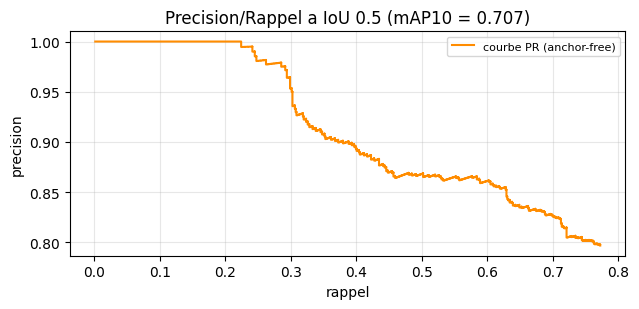

In [11]:
def collect_pr(model, X, B, conf=0.3):
    """Toutes les detections du jeu, triees par score : flags TP/FP + nb de GT."""
    tp_s, fp_s, ngt = [], [], 0
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            dets, dscores = detect(model, X[i:i + 1], conf=conf)
            gts = B[i].to(DEVICE)
            matched = torch.zeros(len(gts), dtype=torch.bool, device=DEVICE)
            for d in dscores.argsort(descending=True).tolist():
                if len(gts):
                    ious = iou_t(dets[d:d + 1].to(DEVICE), gts)[0]
                    ious[matched] = -1
                    g = int(ious.argmax())
                    if ious[g] >= 0.5:
                        matched[g] = True; tp_s.append(float(dscores[d])); continue
                fp_s.append(float(dscores[d]))
            ngt += len(B[i])
    return tp_s, fp_s, ngt


def ap_voc(tp_s, fp_s, ngt):
    """Identique a 4.2c : VOC07 11-point + VOC10 all-point."""
    flags = np.array([1] * len(tp_s) + [0] * len(fp_s), dtype=np.float64)
    scores = np.array(tp_s + fp_s, dtype=np.float64)
    order = np.argsort(-scores)
    flags, scores = flags[order], scores[order]
    ctp, cfp = np.cumsum(flags), np.cumsum(1 - flags)
    rec = ctp / max(ngt, 1)
    prec = ctp / np.maximum(ctp + cfp, 1e-9)
    mrec = np.concatenate([[0], rec, [1]])
    mpre = np.concatenate([[0], prec, [0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    ap10 = float(np.sum((mrec[1:] - mrec[:-1]) * mpre[1:]))
    ap07 = 0.0
    for t in np.linspace(0, 1, 11):
        sel = rec >= t
        ap07 += (prec[sel].max() if sel.any() else 0.0) / 11
    return ap07, ap10, rec, prec


tp_s, fp_s, ngt = collect_pr(model, Xva, Bva)
ap07, ap10, rec, prec = ap_voc(tp_s, fp_s, ngt)
print(f"ANCHOR-FREE : mAP@0.5 sur {len(Xva)} images / {ngt} objets GT : "
      f"VOC07 11-point {ap07:.3f} | VOC10 all-point {ap10:.3f}")

plt.figure(figsize=(6.5, 3.2))
plt.step(rec, prec, where="post", color="darkorange", label="courbe PR (anchor-free)")
plt.xlabel("rappel"); plt.ylabel("precision")
plt.title(f"Precision/Rappel a IoU 0.5 (mAP10 = {ap10:.3f})")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 9. Comparaison avec l'approche à anchors : ce qui a été acheté, ce qui a été payé

Les deux notebooks tournent sur **exactement le même terrain et le même harnais**. Les chiffres de 4.2c sont ceux committés dans ses sorties ; ils ne sont pas recalculés ici, précisément pour que la comparaison porte sur deux mesures indépendantes.

Un préalable de méthode, parce qu'un mAP ne se compare qu'à capacité comparable. Le modèle livré ici compte **83 621 paramètres contre 74 717 à 4.2c** — deux comptages commis dans les sorties respectives — soit un léger avantage de capacité côté anchor-free, pas un handicap. L'écart mesure donc la méthode, pas la taille du réseau.

Et le verdict est net : **l'anchor-free fait moins bien ici**, et l'écart se creuse sur le mAP10. Avant d'en tirer une leçon, il faut voir ce que ce terrain a d'exceptionnel pour l'anchor-based : des objets dont la taille varie d'un facteur 3 (14 à 44 pixels), exactement ce que la grille à 3 échelles de priors couvre gratuitement. La tête `size` de CenterNet, elle, doit régresser toute cette plage depuis une seule feature map. L'écart mesuré chiffre ce que coûtent des priors absents — sur un terrain taillé pour eux.

La colonne « prior géométrique » est l'autre lecture du même écart : 5 184 hypothèses pré-posées par image contre zéro. Les 5 hyperparamètres que 4.2c a dus choisir n'ont pas été payés ici — mais l'ablation de 4.2c (grille carrée contre grille complète) montrait que la grille la plus riche ne faisait pas mieux : le travail de conception de la grille peut coûter sans rien rapporter.

In [12]:
# chiffres committes dans les sorties de 4.2c (relus, non recalcules)
A1_MAP07, A1_MAP10 = 0.853, 0.914
A1_GRID_SQ07, A1_GRID_SQ10 = 0.864, 0.926
A1_ANC_FULL = 24 * 24 * 9      # 3 tailles x 3 ratios
A1_ANC_SQ = 24 * 24 * 3

print("=" * 74)
print("%-30s %10s %10s %10s" % ("", "mAP07", "mAP10", "prior geometrique"))
print("-" * 74)
print("%-30s %10.3f %10.3f %10s" % ("4.2c anchor-based (grille 3x3)", A1_MAP07, A1_MAP10,
                                    f"{A1_ANC_FULL} anchors"))
print("%-30s %10.3f %10.3f %10s" % ("4.2c anchor-based (grille carree)", A1_GRID_SQ07,
                                    A1_GRID_SQ10, f"{A1_ANC_SQ} anchors"))
print("%-30s %10.3f %10.3f %10s" % ("4.2d anchor-free (CenterNet-like)", ap07, ap10, "0 anchor"))
print("=" * 74)
print("ecart anchor-free - anchor-based (grille 3x3) : %+.1f pts de mAP07, %+.1f pts de mAP10"
      % (100 * (ap07 - A1_MAP07), 100 * (ap10 - A1_MAP10)))
print()
print("Ce que l'anchor-free n'a PAS eu a choisir : tailles, ratios, seuils d'assignation.")
print("Ce que l'anchor-based a choisi (3 tailles x 3 ratios + POS_THR/NEG_THR) : 5 hyperparametres.")

                                    mAP07      mAP10 prior geometrique
--------------------------------------------------------------------------
4.2c anchor-based (grille 3x3)      0.853      0.914 5184 anchors
4.2c anchor-based (grille carree)      0.864      0.926 1728 anchors
4.2d anchor-free (CenterNet-like)      0.673      0.707   0 anchor
ecart anchor-free - anchor-based (grille 3x3) : -18.0 pts de mAP07, -20.7 pts de mAP10

Ce que l'anchor-free n'a PAS eu a choisir : tailles, ratios, seuils d'assignation.
Ce que l'anchor-based a choisi (3 tailles x 3 ratios + POS_THR/NEG_THR) : 5 hyperparametres.


## 10. Ablation : à quoi sert réellement la tête d'offset ?

La tête d'offset est le seul organe du modèle qui n'existe **que** parce qu'on a discrétisé l'espace. Un centre d'objet vit à une coordonnée continue $c_x$ ; le réseau ne peut le désigner que par la cellule qui le contient, d'où une erreur de quantification allant jusqu'à une demi-cellule — soit 2 pixels ici.

La question empirique est de savoir si cette erreur pèse. On la mesure en décodant le **même modèle entraîné** sans appliquer l'offset, c'est-à-dire en ramenant chaque centre prédit sur le coin de sa cellule. Toutes les autres pièces — poids, pics, NMS, appariement — restent identiques : la différence ne peut venir que de l'offset.

La mesure est sans ambiguïté : le retirer coûte ici **plus de 6 points de mAP07 et 10 points de mAP10** — de loin l'organe dont la suppression dégrade le plus le score. La distribution des cibles le confirme mécaniquement : l'écart-type mesuré des offsets (~0,29) colle à celui d'une loi uniforme sur $[-0.5, 0.5]$ ($1/\sqrt{12} \approx 0{,}289$) — la cible est bien une erreur d'arrondi uniforme, et la tête la compense exactement. C'est un cas rare d'ablation dont le résultat se lit avant même l'expérience, et qui la vérifie quand même : le gain vient de la disparition d'une erreur de quantification, pas d'un effet d'entraînement.

In [13]:
tp_s2, fp_s2, ngt2 = collect_pr(model, Xva, Bva, conf=0.3, )
# meme modele, mais on ignore l'offset au decodage
def collect_pr_no_offset(model, X, B, conf=0.3):
    tp_s, fp_s, ngt = [], [], 0
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            dets, dscores = detect(model, X[i:i + 1], conf=conf, use_offset=False)
            gts = B[i].to(DEVICE)
            matched = torch.zeros(len(gts), dtype=torch.bool, device=DEVICE)
            for d in dscores.argsort(descending=True).tolist():
                if len(gts):
                    ious = iou_t(dets[d:d + 1].to(DEVICE), gts)[0]
                    ious[matched] = -1
                    g = int(ious.argmax())
                    if ious[g] >= 0.5:
                        matched[g] = True; tp_s.append(float(dscores[d])); continue
                fp_s.append(float(dscores[d]))
            ngt += len(B[i])
    return tp_s, fp_s, ngt


tp0, fp0, ng0 = collect_pr_no_offset(model, Xva, Bva)
ap07_no, ap10_no, _, _ = ap_voc(tp0, fp0, ng0)
print("avec offset    : mAP07 %.3f | mAP10 %.3f" % (ap07, ap10))
print("sans offset    : mAP07 %.3f | mAP10 %.3f" % (ap07_no, ap10_no))
print("gain de l'offset : %+.1f pts de mAP07, %+.1f pts de mAP10"
      % (100 * (ap07 - ap07_no), 100 * (ap10 - ap10_no)))

# ou va l'erreur de quantification : distribution des offsets cibles
off_val = VA_off.permute(0, 2, 3, 1)[VA_msk > 0]
print("offset cible : moyenne (%.3f, %.3f) | ecart-type (%.3f, %.3f) — "
      "une distribution uniforme sur [-0.5, 0.5] aurait un ecart-type de %.3f"
      % (off_val[:, 0].mean(), off_val[:, 1].mean(), off_val[:, 0].std(),
         off_val[:, 1].std(), 1 / math.sqrt(12)))

avec offset    : mAP07 0.673 | mAP10 0.707
sans offset    : mAP07 0.610 | mAP10 0.606
gain de l'offset : +6.3 pts de mAP07, +10.0 pts de mAP10
offset cible : moyenne (0.430, 0.397) | ecart-type (0.287, 0.291) — une distribution uniforme sur [-0.5, 0.5] aurait un ecart-type de 0.289


## 11. La limite structurelle : deux centres sur la même cellule

L'anchor-free n'est pas gratuit, et son défaut propre mérite d'être mesuré plutôt que récité.

Un anchor-based peut, en principe, détecter deux objets qui se chevauchent beaucoup : deux anchors différents peuvent être positifs pour deux GT différents, et l'assignation par IoU les distingue. L'anchor-free, lui, désigne un objet **par une cellule**. Si deux objets ont leur centre dans la même cellule — ou dans deux cellules voisines que le max-pool $3 \times 3$ fusionne — la méthode ne peut structurellement pas les séparer. Un seul pic survivra.

Le phénomène dépend du `STRIDE` : plus la sortie est grossière, plus la cellule est grande, plus la collision est probable. C'est la raison pour laquelle CenterNet complet remonte à la résolution d'entrée.

Mesurons plutôt que de supposer. Sur les 285 images de validation qui contiennent au moins deux objets : distance minimale entre centres **2,24 px**, 2 paires seulement à moins d'un stride, et **zéro collision effective** (deux GT sur la même cellule) sur 817 objets. La limite est réelle — le contrôle positif forcé la détecte bien — mais ce terrain la tient à l'écart : sa contrainte de non-recouvrement (IoU < 0,25) écarte les centres les uns des autres (médiane 27 px). Sur un jeu dense — piétons vus de loin, cellules en microscopie — ce serait une autre histoire, et c'est précisément le genre de terrain qui décide entre les deux paradigmes.

In [14]:
# distance minimale entre centres de deux objets d'une meme image
def centre_distances(B):
    d = []
    for b in B:
        if len(b) < 2:
            continue
        bc = torch.stack([b[:, 0] + b[:, 2] / 2, b[:, 1] + b[:, 3] / 2], dim=1)
        dist = torch.cdist(bc, bc)
        dist.fill_diagonal_(float("inf"))
        d.append(dist.min().item())
    return np.array(d)


dmin = centre_distances(Bva)
print("objets val : %d | images a >=2 objets : %d" % (sum(len(b) for b in Bva), len(dmin)))
print("distance minimale entre centres : min %.2f px | mediane %.2f px | moyenne %.2f px"
      % (dmin.min(), np.median(dmin), dmin.mean()))
for seuil, nom in [(STRIDE, "meme cellule / max-pool (<= stride, 1 cellule)"),
                   (2 * STRIDE, "adjacents (<= 2 cellules)")]:
    n = int((dmin <= seuil).sum())
    print("  paires a <= %2d px (%-38s) : %2d / %d" % (seuil, nom, n, len(dmin)))

# collisions effectives : deux GT dont les centres tombent sur la MEME cellule
coll = 0
for b in Bva:
    cells = set()
    for (x0, y0, w, h) in b.tolist():
        cells.add((int((x0 + w / 2) / STRIDE), int((y0 + h / 2) / STRIDE)))
    coll += len(b) - len(cells)
print("collisions effectives (deux GT sur la meme cellule) : %d objet(s) sur %d"
      % (coll, sum(len(b) for b in Bva)))

# controle positif de l'instrument : on force deux objets a se superposer au centre
_probe = torch.tensor([[20.0, 20.0, 20.0, 20.0], [21.0, 21.0, 18.0, 18.0]])
_cells = set()
for (x0, y0, w, h) in _probe.tolist():
    _cells.add((int((x0 + w / 2) / STRIDE), int((y0 + h / 2) / STRIDE)))
print("controle positif (centres a 1,4 px, force) : %d cellules distinctes pour 2 objets -> %s"
      % (len(_cells), "collision detectee" if len(_cells) < 2 else "INSTRUMENT MUET"))

objets val : 817 | images a >=2 objets : 285
distance minimale entre centres : min 2.24 px | mediane 27.24 px | moyenne 29.61 px
  paires a <=  4 px (meme cellule / max-pool (<= stride, 1 cellule)) :  2 / 285
  paires a <=  8 px (adjacents (<= 2 cellules)             ) :  5 / 285
collisions effectives (deux GT sur la meme cellule) : 0 objet(s) sur 817
controle positif (centres a 1,4 px, force) : 1 cellules distinctes pour 2 objets -> collision detectee


## 12. Limites et suite

**Ce que ce notebook établit.** Qu'une détection sans aucun prior géométrique fonctionne de bout en bout — cibles, loss focale, décodage, mAP honorable — mais qu'elle rend ici une mesure **inférieure** à l'approche à anchors, à capacité de modèle comparable ; et pourquoi : un terrain de tailles étalées (facteur 3) favorise précisément les priors multi-échelles que l'anchor-free n'a pas.

**Ce qu'il ne faut pas en conclure.** Que l'anchor-based serait « meilleur » en général. Les deux méthodes échangent des défauts différents — conception de la grille contre quantification et collision de centres — et ce notebook en a mesuré un de chaque côté : plus de 6 points de mAP07 pour l'offset (section 10), zéro collision effective sur ce terrain clément (section 11).

**Ce que le notebook ne fait pas, et qui conditionne le verdict :**

- Une seule **graine**, aucune barre d'erreur. L'écart mesuré est trop grand — et mesuré à capacité légèrement supérieure à 4.2c (section 9) — pour être un artefact de taille de modèle, mais sa magnitude exacte reste indicative.
- Une seule **classe** (« objet ») : aucun conflit inter-classes sur une même cellule, un problème réel de CenterNet sur des jeux multi-classes.
- Le terrain est **synthétique** et généreux : objets contrastés, fond lisse, non-recouvrement garanti. Les chiffres absolus ne se transposent à aucun jeu réel.
- `STRIDE = 4` est fixé ; le compromis précision/collision en fonction du stride n'est pas balayé.

**La suite de la série.** Le bloc A.3 traite la Focal Loss pour elle-même, sur un déséquilibre extrême contrôlé (1000 négatifs pour 1 positif) — ici elle n'apparaît que comme un ingrédient de CenterNet. Le bloc B confronte ces implantations de référence aux implémentations SOTA (`torchvision.models.detection` : Faster R-CNN, RetinaNet, FCOS ; `ultralytics` : YOLO), sur un tableau mAP / latence / taille de modèle.

### Exercice 1 — Le rayon de la gaussienne

La fonction `gaussian_radius` implémente la règle de CenterNet : le rayon maximal tel qu'un pic déplacé conserve un IoU d'au moins 0,7.

Écrivez `radius_vs_overlap(sizes, min_overlap)` qui, pour une liste de tailles d'objets (en pixels, avant division par le stride), retourne le rayon obtenu pour plusieurs valeurs de `min_overlap` — et vérifiez empiriquement la propriété annoncée : en déplaçant le pic du rayon calculé sur chaque axe, l'IoU avec l'objet reste au-dessus du seuil demandé (et casse dès le pixel suivant).

*Indice : la vérification se fait en construisant une boîte décalée de `radius` pixels sur chaque axe et en appelant `iou_np`. Un rayon issu d'un `floor` devrait donner un IoU légèrement supérieur au seuil, jamais inférieur.*

In [15]:
def radius_vs_overlap(sizes, min_overlap):
    """Exercice 1 : rayon de gaussienne pour plusieurs tailles et seuils.

    Retourne un dict {min_overlap: [rayon pour chaque taille]}.
    """
    # TODO etudiant
    # Etape 1 : diviser chaque taille par le STRIDE (la regle vit en unites de sortie)
    # Etape 2 : appeler gaussian_radius sur (h, w) arrondis au superieur
    # Etape 3 : verifier la propriete avec iou_np sur une boite decalee du rayon
    return None  # TODO etudiant


print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — La NMS centroïde

La NMS gloutonne de la section 7 raisonne en **IoU sur les boîtes**. C'est la NMS historique, héritée du monde à anchors.

L'anchor-free a une alternative naturelle : supprimer une détection si son **centre** est trop proche d'un centre déjà conservé. Le raisonnement est que, dans ce paradigme, deux objets distincts ont deux centres distincts — et deux pics proches décrivent donc le même objet. Cette NMS ne dépend ni de la largeur, ni de la hauteur, ni du chevauchement des boîtes, seulement d'une distance.

Écrivez `nms_centroid(boxes, scores, dist_thr)` où `dist_thr` est exprimé en **fraction de la taille** de la boîte conservée (par exemple `0.7 * max(w, h)`), puis comparez le mAP obtenu à celui de la NMS gloutonne.

*Indice : trier par score décroissant, conserver le premier, supprimer tout candidat dont le centre est à une distance inférieure au seuil relatif à la boîte conservée. Attention à l'échelle : les tailles d'objets varient d'un facteur 3 sur ce terrain.*

In [16]:
def nms_centroid(boxes, scores, dist_thr=0.7):
    """Exercice 2 : NMS sur la distance des centres (pas sur l'IoU des boites).

    Retourne la liste des indices conserves.
    """
    # TODO etudiant
    # Etape 1 : centres = (x0 + w/2, y0 + h/2)
    # Etape 2 : trier par score decroissant
    # Etape 3 : pour chaque boite restante, supprimer les candidates dont le centre
    #           est a moins de dist_thr * max(w, h) de la boite conservee
    return None  # TODO etudiant


print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Décodage par top-k sans max-pool

Le max-pool $3 \times 3$ de la section 7 est une heuristique de fenêtre fixe. Une autre lecture de CenterNet consiste à se passer entièrement d'extraction de pics et à prendre directement les $k$ cellules les plus fortes de la heatmap, en s'en remettant à la NMS pour démêler les grappes qu'un même objet produit.

Écrivez `decode_topk_only(hm, off, siz, k, conf)` qui décode sans max-pool, mesurez le mAP, et regardez le **nombre de détections avant NMS** dans les deux variantes.

*Indice : la question intéressante n'est pas seulement le mAP — les deux variantes peuvent tomber d'accord après NMS tout en produisant des nombres de détections brutes très différents. C'est ce que le comptage révèle.*

In [17]:
def decode_topk_only(hm, off, siz, k=100, conf=0.3):
    """Exercice 3 : decodage par top-k global, sans max-pool 3x3.

    Retourne (boites, scores).
    """
    # TODO etudiant
    # Etape 1 : sigmoide de la heatmap, sans extraction de pics
    # Etape 2 : top-k global sur les cellules au-dessus de conf
    # Etape 3 : reconstruire les boites (cf. decode_centernet) — et COMPTER
    #           les detections brutes avant NMS pour comparer
    return None  # TODO etudiant


print("Exercice 3 a completer")

Exercice 3 a completer

## Conclusion

La détection anchor-free renverse la question de la section 1 de 4.2c. Là où l'approche à anchors demandait *« lequel de mes priors correspond à cet objet ? »*, CenterNet demande *« cet objet a-t-il un centre, et où ? »* — et cette reformulation fait disparaître toute une famille d'hyperparamètres : plus de tailles, plus de ratios, plus de seuils d'assignation, plus d'échantillonnage. Le réseau ne corrige plus des hypothèses posées à la main, il prédit un point.

Trois conséquences structurelles se sont dégagées au fil du notebook :

1. **La cible devient continue.** La gaussienne remplace l'étiquette binaire, et le facteur $(1-y)^4$ de la loss fait qu'une cellule voisine du centre est traitée comme *presque correcte* plutôt que comme du fond — la mesure de la section 5 le vérifie au millième : un faux positif confiant sur un voisin à $y = 0{,}6$ coûte 2,56 % de ce qu'il coûterait sur du fond pur.
2. **La loss doit porter le déséquilibre.** Sans échantillonnage, plus de 99 % des cellules sont du fond ; c'est la focal loss qui empêche la solution triviale « rien nulle part » de l'emporter, avec sa normalisation par le nombre d'objets et non par le nombre de cellules.
3. **Le paradigme a ses propres coûts.** La discrétisation impose une tête d'offset qui vaut ici plus de 6 points de mAP07, et deux objets dont les centres tombent sur la même cellule sont structurellement indistinguables — limite réelle mais non sollicitée par ce terrain.

La comparaison avec 4.2c, à terrain, harnais et capacité comparables, tombe **en faveur des anchors ici** : sur des objets étalés d'un facteur 3 en taille, les priors multi-échelles sont un avantage réel, pas un confort. La leçon n'est pas qu'une famille surclasse l'autre — un terrain dense d'objets de taille homogène inverserait probablement le tableau, et le bloc B mesurera ce que ces familles deviennent dans leurs implémentations SOTA complètes. La leçon est que **le choix du prior est une décision de conception qui se chiffre** : sur ce terrain, cinq hyperparamètres de grille achètent 18 points de mAP07 ; sur un autre, ils n'achèteront que des conflits à arbitrer à la main. C'est un compromis à mesurer à chaque jeu de données, pas un dogme à décréter.